In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import random
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully!")

mkdir -p failed for path C:\Users\yasha\.matplotlib: [WinError 5] Access is denied: 'C:\\Users\\yasha\\.matplotlib'
Matplotlib created a temporary cache directory at C:\Users\yasha\AppData\Local\Temp\matplotlib-tlx_vahx because there was an issue with the default path (C:\Users\yasha\.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Libraries loaded successfully!


In [2]:
random.seed(42)
num_rows = 1000
categories = ['Electronics', 'Clothing', 'Books', 'Home & Kitchen', 'Sports']
cities = ['Bengaluru', 'Mumbai', 'Delhi', 'Hyderabad', 'Chennai']

data = {
    'order_id':    [f"ORD{str(i).zfill(4)}" for i in range(1, num_rows + 1)],
    'customer_id': [f"CUST{random.randint(1, 200):03d}" for _ in range(num_rows)],
    'category':    [random.choice(categories) for _ in range(num_rows)],
    'city':        [random.choice(cities) for _ in range(num_rows)],
    'order_date':  pd.date_range(start='2023-01-01', periods=num_rows, freq='8H'),
    'amount':      [round(random.uniform(200, 15000), 2) for _ in range(num_rows)],
    'quantity':    [random.randint(1, 5) for _ in range(num_rows)],
}

df = pd.DataFrame(data)
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')

print("Dataset Created!")
print("Shape:", df.shape)
print(df.head())

Dataset Created!
Shape: (1000, 9)
  order_id customer_id     category       city          order_date    amount  \
0  ORD0001     CUST164     Clothing  Bengaluru 2023-01-01 00:00:00   5939.43   
1  ORD0002     CUST029        Books      Delhi 2023-01-01 08:00:00   1453.55   
2  ORD0003     CUST007  Electronics    Chennai 2023-01-01 16:00:00  13536.81   
3  ORD0004     CUST190       Sports      Delhi 2023-01-02 00:00:00  13597.07   
4  ORD0005     CUST071     Clothing     Mumbai 2023-01-02 08:00:00  14676.96   

   quantity  month month_name  
0         3      1        Jan  
1         3      1        Jan  
2         3      1        Jan  
3         2      1        Jan  
4         2      1        Jan  


In [3]:
print("Checking Missing Values:")
print(df.isnull().sum())
df = df.dropna()
print("Basic Stats:")
print(df['amount'].describe())

Checking Missing Values:
order_id       0
customer_id    0
category       0
city           0
order_date     0
amount         0
quantity       0
month          0
month_name     0
dtype: int64
Basic Stats:
count     1000.000000
mean      7590.447020
std       4314.440547
min        210.000000
25%       3894.715000
50%       7557.620000
75%      11337.077500
max      14998.510000
Name: amount, dtype: float64


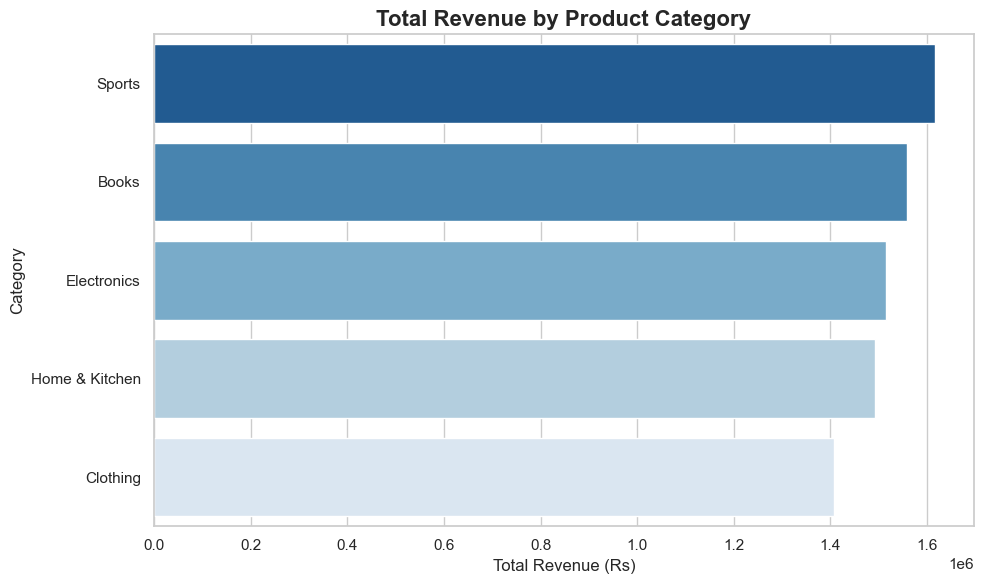

Chart 1 saved!


In [4]:
plt.figure(figsize=(10, 6))
category_revenue = df.groupby('category')['amount'].sum().sort_values(ascending=False)
sns.barplot(x=category_revenue.values, y=category_revenue.index, palette="Blues_r")
plt.title("Total Revenue by Product Category", fontsize=16, fontweight='bold')
plt.xlabel("Total Revenue (Rs)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.tight_layout()
plt.savefig("chart1_category_revenue.png", dpi=150)
plt.show()
print("Chart 1 saved!")

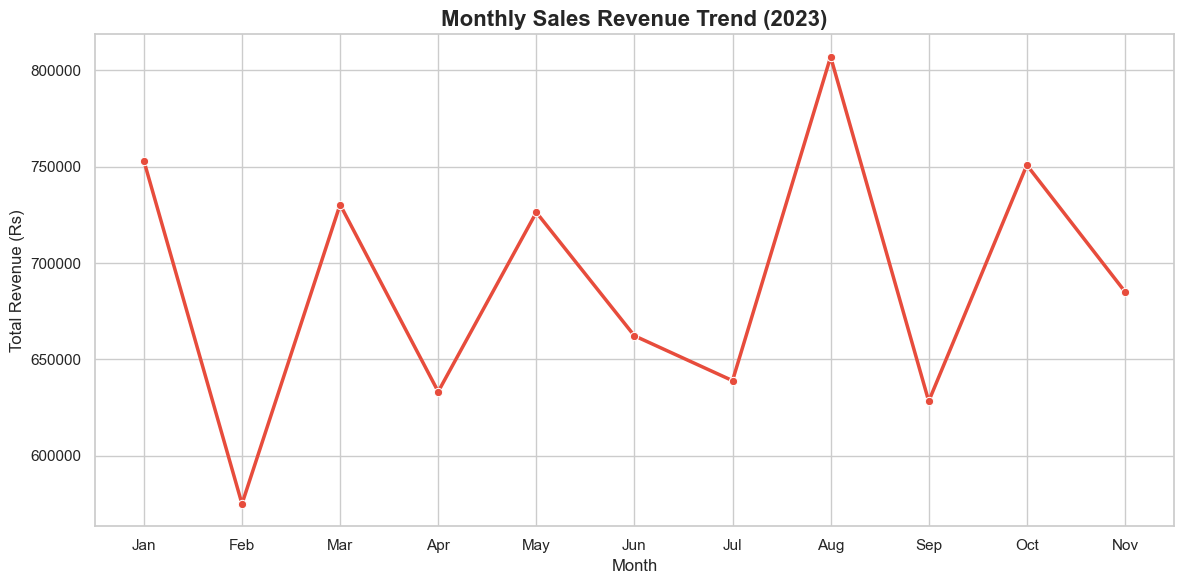

Chart 2 saved!


In [5]:
plt.figure(figsize=(12, 6))
monthly_sales = df.groupby('month')['amount'].sum()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values,
             marker='o', color='#E74C3C', linewidth=2.5)
plt.xticks(ticks=monthly_sales.index, labels=month_labels[:len(monthly_sales)])
plt.title("Monthly Sales Revenue Trend (2023)", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue (Rs)", fontsize=12)
plt.tight_layout()
plt.savefig("chart2_monthly_trend.png", dpi=150)
plt.show()
print("Chart 2 saved!")

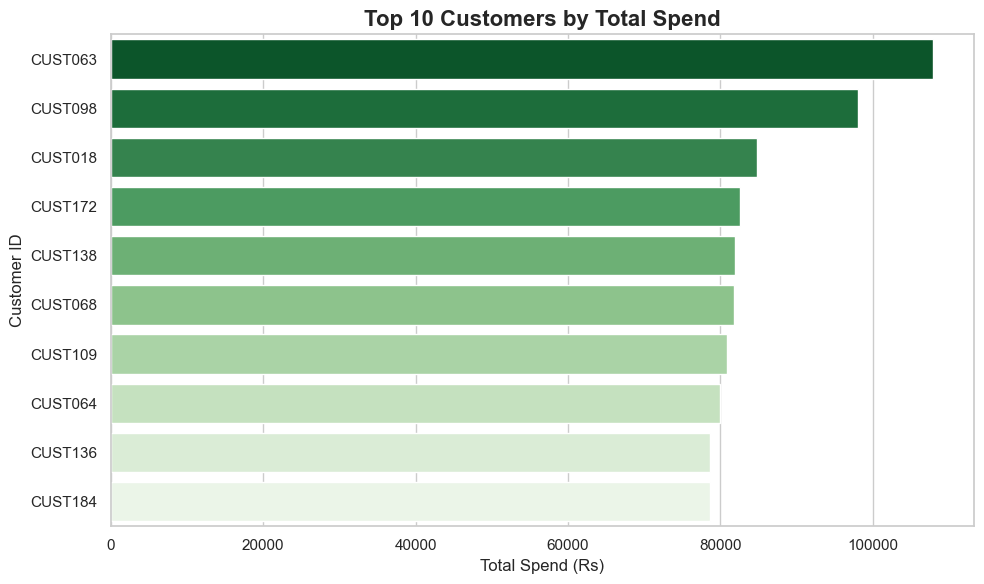

Chart 3 saved!


In [6]:
plt.figure(figsize=(10, 6))
top_customers = df.groupby('customer_id')['amount'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_customers.values, y=top_customers.index, palette="Greens_r")
plt.title("Top 10 Customers by Total Spend", fontsize=16, fontweight='bold')
plt.xlabel("Total Spend (Rs)", fontsize=12)
plt.ylabel("Customer ID", fontsize=12)
plt.tight_layout()
plt.savefig("chart3_top_customers.png", dpi=150)
plt.show()
print("Chart 3 saved!")

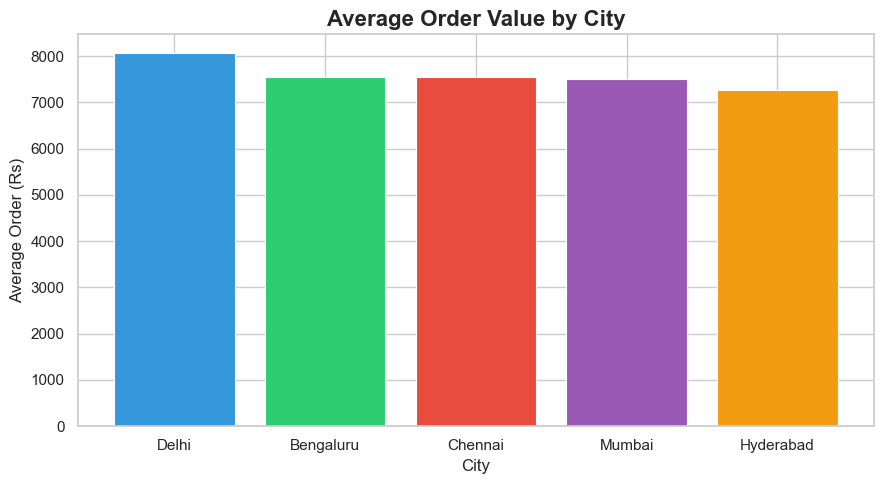

Chart 4 saved!


In [7]:
plt.figure(figsize=(9, 5))
city_avg = df.groupby('city')['amount'].mean().sort_values(ascending=False)
colors = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6', '#F39C12']
plt.bar(city_avg.index, city_avg.values, color=colors, edgecolor='white', linewidth=0.8)
plt.title("Average Order Value by City", fontsize=16, fontweight='bold')
plt.xlabel("City", fontsize=12)
plt.ylabel("Average Order (Rs)", fontsize=12)
plt.tight_layout()
plt.savefig("chart4_city_avg.png", dpi=150)
plt.show()
print("Chart 4 saved!")

In [8]:
conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')

query1 = """
SELECT category,
       ROUND(SUM(amount), 2) AS total_revenue,
       COUNT(*) AS total_orders
FROM sales
GROUP BY category
ORDER BY total_revenue DESC;
"""
result1 = pd.read_sql_query(query1, conn)
print("Revenue by Category:")
print(result1.to_string(index=False))

query2 = """
SELECT month,
       ROUND(SUM(amount), 2) AS monthly_revenue,
       COUNT(*) AS orders
FROM sales
GROUP BY month
ORDER BY month ASC;
"""
result2 = pd.read_sql_query(query2, conn)
print("\nMonthly Revenue:")
print(result2.to_string(index=False))

query3 = """
SELECT customer_id,
       ROUND(SUM(amount), 2) AS total_spent,
       COUNT(*) AS orders_placed
FROM sales
GROUP BY customer_id
ORDER BY total_spent DESC
LIMIT 5;
"""
result3 = pd.read_sql_query(query3, conn)
print("\nTop 5 Customers:")
print(result3.to_string(index=False))

query4 = """
SELECT city,
       ROUND(SUM(amount), 2) AS total_revenue,
       ROUND(AVG(amount), 2) AS avg_order_value,
       COUNT(*) AS total_orders
FROM sales
GROUP BY city
ORDER BY total_revenue DESC;
"""
result4 = pd.read_sql_query(query4, conn)
print("\nCity Performance:")
print(result4.to_string(index=False))

query5 = """
SELECT category, city,
       ROUND(SUM(amount), 2) AS revenue
FROM sales
GROUP BY category, city
ORDER BY revenue DESC
LIMIT 10;
"""
result5 = pd.read_sql_query(query5, conn)
print("\nTop Category-City Combinations:")
print(result5.to_string(index=False))

conn.close()
print("\nAll SQL queries done!")

Revenue by Category:
      category  total_revenue  total_orders
        Sports     1616353.20           202
         Books     1558666.85           206
   Electronics     1515825.09           204
Home & Kitchen     1492964.22           210
      Clothing     1406637.66           178

Monthly Revenue:
 month  monthly_revenue  orders
     1        752961.37      93
     2        575167.87      84
     3        730281.24      93
     4        633328.05      90
     5        726249.45      93
     6        662277.35      90
     7        639037.60      93
     8        806844.18      93
     9        628378.96      90
    10        750756.58      93
    11        685164.37      88

Top 5 Customers:
customer_id  total_spent  orders_placed
    CUST063    107892.54             10
    CUST098     98074.05             11
    CUST018     84851.71             10
    CUST172     82567.20             10
    CUST138     81970.91             10

City Performance:
     city  total_revenue  avg_order_

In [9]:
print("="*55)
print("KEY BUSINESS INSIGHTS")
print("="*55)

top_category = df.groupby('category')['amount'].sum().idxmax()
print(f"Highest Revenue Category : {top_category}")

top_city = df.groupby('city')['amount'].sum().idxmax()
print(f"Top Revenue City         : {top_city}")

best_avg_city = df.groupby('city')['amount'].mean().idxmax()
print(f"Highest Avg Order City   : {best_avg_city}")

top_customer = df.groupby('customer_id')['amount'].sum().idxmax()
print(f"Top Spending Customer    : {top_customer}")

total_revenue = df['amount'].sum()
print(f"Total Revenue            : Rs {total_revenue:,.2f}")

repeat_customers = df['customer_id'].value_counts()
repeat_count = (repeat_customers > 1).sum()
print(f"Repeat Customers         : {repeat_count} out of 200")

print("\nAnalysis Complete!")

KEY BUSINESS INSIGHTS
Highest Revenue Category : Sports
Top Revenue City         : Delhi
Highest Avg Order City   : Delhi
Top Spending Customer    : CUST063
Total Revenue            : Rs 7,590,447.02
Repeat Customers         : 193 out of 200

Analysis Complete!


In [10]:
df.to_csv("ecommerce_data.csv", index=False)
print("CSV saved successfully!")

CSV saved successfully!
